In [8]:
pip install ucimlrepo

In [9]:
from ucimlrepo import fetch_ucirepo

covertype = fetch_ucirepo(id=31)

X = covertype.data.features
y = covertype.data.targets

print(covertype.metadata)

print(covertype.variables)


{'uci_id': 31, 'name': 'Covertype', 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype', 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv', 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 581012, 'num_features': 54, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['Cover_Type'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C50K5N', 'creators': ['Jock Blackard'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell) was determined from

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

np.random.seed(42)



print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFirst 5 rows of features:")
print(X.head())

print("\nFirst 5 target values:")
print(y.head())

print("\nTarget column:")
print(y.columns)

print("\nMissing values:")
print(X.isnull().sum().sum())
print(y.isnull().sum().sum())


Feature shape: (581012, 54)
Target shape: (581012, 1)

First 5 rows of features:
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1    

In [11]:
X = X.to_numpy(dtype=np.float64)

y = y.iloc[:, 0].to_numpy(dtype=np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Unique classes:", np.unique(y))


X shape: (581012, 54)
y shape: (581012,)
Unique classes: [1 2 3 4 5 6 7]


In [12]:

class_counts = pd.Series(y).value_counts().sort_index()

print("\nClass distribution:")
print(class_counts)

class_percentages = (
    class_counts / len(y) * 100
)

print("\nClass percentages:")
print(class_percentages.round(2))



Class distribution:
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64

Class percentages:
1    36.46
2    48.76
3     6.15
4     0.47
5     1.63
6     2.99
7     3.53
Name: count, dtype: float64


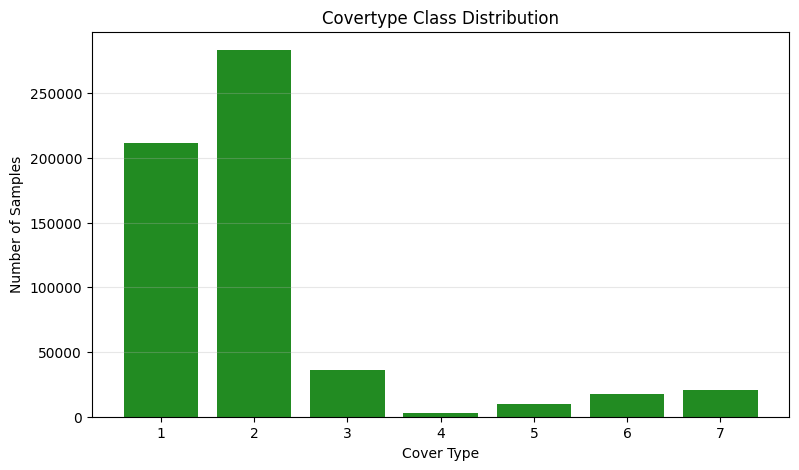

In [13]:
plt.figure(figsize=(9, 5))

plt.bar(
    class_counts.index,
    class_counts.values,
    color="forestgreen"
)

plt.xlabel("Cover Type")
plt.ylabel("Number of Samples")
plt.title("Covertype Class Distribution")
plt.xticks(range(1, 8))
plt.grid(axis="y", alpha=0.3)

plt.show()


In [14]:
most_frequent = class_counts.max()
least_frequent = class_counts.min()

most_frequent_class = class_counts.idxmax()
least_frequent_class = class_counts.idxmin()

imbalance_ratio = (
    most_frequent / least_frequent
)

print("Most frequent class:", most_frequent_class)
print("Most frequent count:", most_frequent)

print("Least frequent class:", least_frequent_class)
print("Least frequent count:", least_frequent)

print(
    "Imbalance ratio:",
    round(imbalance_ratio, 2)
)


Most frequent class: 2
Most frequent count: 283301
Least frequent class: 4
Least frequent count: 2747
Imbalance ratio: 103.13


In [15]:
y = y - 1

print("Zero-indexed classes:")
print(np.unique(y))

Zero-indexed classes:
[0 1 2 3 4 5 6]


In [16]:
K = 7

Y = np.eye(K)[y]

print("One-hot target shape:", Y.shape)

One-hot target shape: (581012, 7)


In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (464809, 54)
Validation set: (58101, 54)
Test set: (58102, 54)


In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

print("Training mean:", X_train.mean())
print("Training std:", X_train.std())

Training mean: -2.403051624250105e-17
Training std: 0.999999999999942


In [19]:
Y_train = np.eye(K)[y_train]
Y_val = np.eye(K)[y_val]
Y_test = np.eye(K)[y_test]

print("Y_train:", Y_train.shape)
print("Y_val:", Y_val.shape)
print("Y_test:", Y_test.shape)

Y_train: (464809, 7)
Y_val: (58101, 7)
Y_test: (58102, 7)


In [20]:
N = len(y_train)

train_class_counts = np.bincount(
    y_train,
    minlength=K
)

class_weights = (
    N / (K * train_class_counts)
)

print("\nClass weights:")

for c in range(K):
    print(
        f"Class {c + 1}: "
        f"count = {train_class_counts[c]}, "
        f"weight = {class_weights[c]:.4f}"
    )


Class weights:
Class 1: count = 169472, weight = 0.3918
Class 2: count = 226640, weight = 0.2930
Class 3: count = 28603, weight = 2.3215
Class 4: count = 2198, weight = 30.2099
Class 5: count = 7594, weight = 8.7439
Class 6: count = 13894, weight = 4.7791
Class 7: count = 16408, weight = 4.0469


In [21]:
layer_sizes = [54, 64, 32, 16, 7]

print("Network architecture:")
print("Input layer  :", layer_sizes[0])
print("Hidden layer 1:", layer_sizes[1])
print("Hidden layer 2:", layer_sizes[2])
print("Hidden layer 3:", layer_sizes[3])
print("Output layer :", layer_sizes[4])


Network architecture:
Input layer  : 54
Hidden layer 1: 64
Hidden layer 2: 32
Hidden layer 3: 16
Output layer : 7


In [22]:
def initialize_parameters(layer_sizes):

    parameters = {}

    for layer in range(1, len(layer_sizes)):

        n_previous = layer_sizes[layer - 1]
        n_current = layer_sizes[layer]

        parameters[f"W{layer}"] = (
            np.random.randn(
                n_previous,
                n_current
            ) * np.sqrt(2.0 / n_previous)
        )

        parameters[f"b{layer}"] = np.zeros(
            (1, n_current)
        )

    return parameters


parameters = initialize_parameters(layer_sizes)

print("\nParameter shapes:")

for name, value in parameters.items():
    print(name, value.shape)



Parameter shapes:
W1 (54, 64)
b1 (1, 64)
W2 (64, 32)
b2 (1, 32)
W3 (32, 16)
b3 (1, 16)
W4 (16, 7)
b4 (1, 7)


In [23]:
def relu(Z):
    return np.maximum(0, Z)


def relu_derivative(Z):
    return (Z > 0).astype(float)


def softmax(Z):

    Z_shifted = (
        Z - np.max(
            Z,
            axis=1,
            keepdims=True
        )
    )

    exp_Z = np.exp(Z_shifted)

    return (
        exp_Z /
        np.sum(
            exp_Z,
            axis=1,
            keepdims=True
        )
    )


In [24]:
def forward_propagation(X, parameters):

    cache = {}

    Z1 = (
        X @ parameters["W1"]
        + parameters["b1"]
    )

    A1 = relu(Z1)


    Z2 = (
        A1 @ parameters["W2"]
        + parameters["b2"]
    )

    A2 = relu(Z2)

    Z3 = (
        A2 @ parameters["W3"]
        + parameters["b3"]
    )

    A3 = relu(Z3)

    Z4 = (
        A3 @ parameters["W4"]
        + parameters["b4"]
    )

    A4 = softmax(Z4)

    cache["Z1"] = Z1
    cache["A1"] = A1

    cache["Z2"] = Z2
    cache["A2"] = A2

    cache["Z3"] = Z3
    cache["A3"] = A3

    cache["Z4"] = Z4
    cache["A4"] = A4

    return A4, cache


In [25]:
def weighted_cross_entropy(
    Y,
    probabilities,
    class_weights
):

    epsilon = 1e-12

    probabilities = np.clip(
        probabilities,
        epsilon,
        1.0 - epsilon
    )
    sample_weights = (
        Y @ class_weights
    )

    loss = -np.sum(
        sample_weights *
        np.sum(
            Y * np.log(probabilities),
            axis=1
        )
    ) / len(Y)

    return loss


In [26]:


def backward_propagation(
    X,
    Y,
    probabilities,
    cache,
    parameters,
    class_weights
):

    m = X.shape[0]

    sample_weights = Y @ class_weights

    dZ4 = (
        probabilities - Y
    )

    dZ4 = (
        dZ4 *
        sample_weights[:, None]
        / m
    )

    dW4 = (
        cache["A3"].T @ dZ4
    )

    db4 = np.sum(
        dZ4,
        axis=0,
        keepdims=True
    )

    dA3 = (
        dZ4 @ parameters["W4"].T
    )

    dZ3 = (
        dA3 *
        relu_derivative(cache["Z3"])
    )

    dW3 = (
        cache["A2"].T @ dZ3
    )

    db3 = np.sum(
        dZ3,
        axis=0,
        keepdims=True
    )

    dA2 = (
        dZ3 @ parameters["W3"].T
    )

    dZ2 = (
        dA2 *
        relu_derivative(cache["Z2"])
    )

    dW2 = (
        cache["A1"].T @ dZ2
    )

    db2 = np.sum(
        dZ2,
        axis=0,
        keepdims=True
    )

    dA1 = (
        dZ2 @ parameters["W2"].T
    )

    dZ1 = (
        dA1 *
        relu_derivative(cache["Z1"])
    )

    dW1 = (
        X.T @ dZ1
    )

    db1 = np.sum(
        dZ1,
        axis=0,
        keepdims=True
    )

    gradients = {
        "W1": dW1,
        "b1": db1,

        "W2": dW2,
        "b2": db2,

        "W3": dW3,
        "b3": db3,

        "W4": dW4,
        "b4": db4
    }

    return gradients


In [27]:
def update_parameters(
    parameters,
    gradients,
    learning_rate
):

    for key in parameters:

        parameters[key] -= (
            learning_rate *
            gradients[key]
        )

    return parameters

In [28]:
def predict(
    X,
    parameters,
    batch_size=8192
):

    all_probabilities = []

    for start in range(
        0,
        len(X),
        batch_size
    ):

        end = min(
            start + batch_size,
            len(X)
        )

        probabilities, _ = (
            forward_propagation(
                X[start:end],
                parameters
            )
        )

        all_probabilities.append(
            probabilities
        )

    return np.vstack(
        all_probabilities
    )

In [29]:
epochs = 100

batch_size = 128

learning_rate = 0.01

patience = 15

best_val_loss = np.inf

best_parameters = None

patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

print("Batch size:", batch_size)
print("Learning rate:", learning_rate)
print("Maximum epochs:", epochs)
print("Early stopping patience:", patience)

Batch size: 128
Learning rate: 0.01
Maximum epochs: 100
Early stopping patience: 15


In [30]:
print("Starting training...\n")

for epoch in range(epochs):

    permutation = np.random.permutation(len(X_train))

    X_train_shuffled = X_train[permutation]
    Y_train_shuffled = Y_train[permutation]

    for start in range(0, len(X_train), batch_size):

        end = min(
            start + batch_size,
            len(X_train)
        )

        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        probabilities, cache = forward_propagation(
            X_batch,
            parameters
        )

        gradients = backward_propagation(
            X_batch,
            Y_batch,
            probabilities,
            cache,
            parameters,
            class_weights
        )

        parameters = update_parameters(
            parameters,
            gradients,
            learning_rate
        )

    train_probabilities = predict(
        X_train,
        parameters
    )

    val_probabilities = predict(
        X_val,
        parameters
    )

    train_loss = weighted_cross_entropy(
        Y_train,
        train_probabilities,
        class_weights
    )

    val_loss = weighted_cross_entropy(
        Y_val,
        val_probabilities,
        class_weights
    )

    train_predictions = np.argmax(
        train_probabilities,
        axis=1
    )

    val_predictions = np.argmax(
        val_probabilities,
        axis=1
    )

    train_accuracy = np.mean(
        train_predictions == y_train
    )

    val_accuracy = np.mean(
        val_predictions == y_val
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    print(
        f"Epoch {epoch + 1:3d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_parameters = {
            key: value.copy()
            for key, value in parameters.items()
        }

        patience_counter = 0

    else:

        patience_counter += 1

        if patience_counter >= patience:

            print("\nEarly stopping triggered.")

            break

print("\nTraining complete.")


Starting training...

Epoch   1/100 | Train Loss: 0.6900 | Val Loss: 0.7041 | Train Acc: 0.5896 | Val Acc: 0.5897
Epoch   2/100 | Train Loss: 0.6319 | Val Loss: 0.6388 | Train Acc: 0.6174 | Val Acc: 0.6167
Epoch   3/100 | Train Loss: 0.5771 | Val Loss: 0.5888 | Train Acc: 0.6476 | Val Acc: 0.6473
Epoch   4/100 | Train Loss: 0.5602 | Val Loss: 0.5766 | Train Acc: 0.6840 | Val Acc: 0.6859
Epoch   5/100 | Train Loss: 0.5388 | Val Loss: 0.5516 | Train Acc: 0.6751 | Val Acc: 0.6759
Epoch   6/100 | Train Loss: 0.5109 | Val Loss: 0.5191 | Train Acc: 0.6814 | Val Acc: 0.6834
Epoch   7/100 | Train Loss: 0.5210 | Val Loss: 0.5357 | Train Acc: 0.7005 | Val Acc: 0.7023
Epoch   8/100 | Train Loss: 0.4897 | Val Loss: 0.4995 | Train Acc: 0.6698 | Val Acc: 0.6701
Epoch   9/100 | Train Loss: 0.4800 | Val Loss: 0.4872 | Train Acc: 0.7132 | Val Acc: 0.7148
Epoch  10/100 | Train Loss: 0.4697 | Val Loss: 0.4797 | Train Acc: 0.7105 | Val Acc: 0.7125
Epoch  11/100 | Train Loss: 0.4549 | Val Loss: 0.4629 | Tr

In [31]:
parameters = best_parameters

print("Best validation loss:", best_val_loss)

print(
    "Number of epochs completed:",
    len(history["train_loss"])
)


Best validation loss: 0.2999912507866349
Number of epochs completed: 100


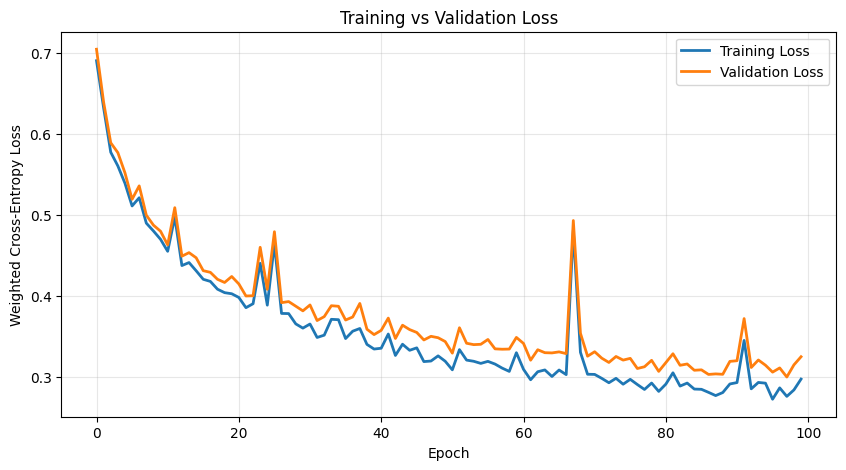

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["train_loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Weighted Cross-Entropy Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


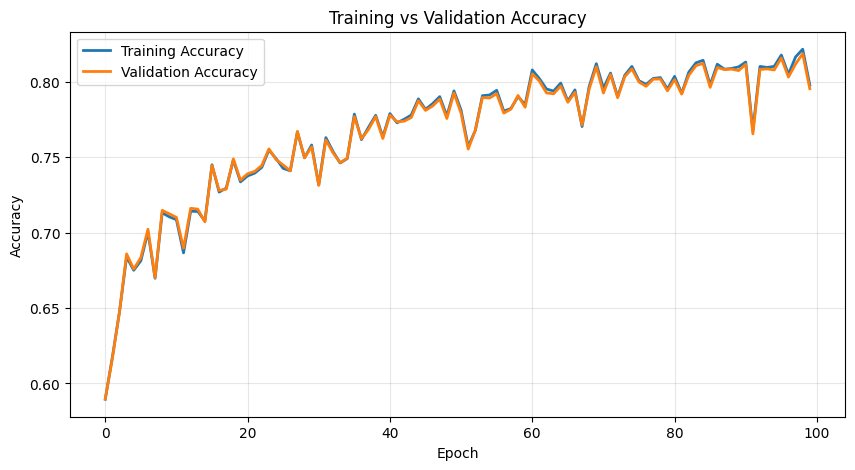

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["train_accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [34]:
test_probabilities = predict(
    X_test,
    parameters
)

print(
    "Test probability shape:",
    test_probabilities.shape
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

print("First 20 predictions:")
print(test_predictions[:20])

print("\nFirst 20 actual classes:")
print(y_test[:20])


Test probability shape: (58102, 7)
First 20 predictions:
[0 4 1 1 5 1 1 1 1 0 1 2 1 0 0 2 0 1 4 0]

First 20 actual classes:
[0 1 1 1 5 1 1 1 1 0 1 3 1 0 0 2 0 1 1 1]


In [35]:
accuracy = accuracy_score(
    y_test,
    test_predictions
)

precision_per_class = precision_score(
    y_test,
    test_predictions,
    average=None,
    zero_division=0
)

recall_per_class = recall_score(
    y_test,
    test_predictions,
    average=None,
    zero_division=0
)

f1_per_class = f1_score(
    y_test,
    test_predictions,
    average=None,
    zero_division=0
)

macro_precision = precision_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

print("\n==========================================")
print("TEST SET RESULTS")
print("==========================================")

print(f"Accuracy          : {accuracy:.4f}")
print(f"Macro Precision   : {macro_precision:.4f}")
print(f"Macro Recall      : {macro_recall:.4f}")
print(f"Macro F1 Score    : {macro_f1:.4f}")



TEST SET RESULTS
Accuracy          : 0.8112
Macro Precision   : 0.6839
Macro Recall      : 0.8879
Macro F1 Score    : 0.7510


In [36]:
metrics_df = pd.DataFrame({
    "Class": np.arange(1, 8),
    "Precision": precision_per_class,
    "Recall": recall_per_class,
    "F1 Score": f1_per_class
})

print("\nPer-class performance:")

print(
    metrics_df.to_string(
        index=False
    )
)



Per-class performance:
 Class  Precision   Recall  F1 Score
     1   0.844222 0.791777  0.817159
     2   0.859422 0.802301  0.829880
     3   0.828849 0.809843  0.819236
     4   0.546012 0.974453  0.699869
     5   0.373786 0.973656  0.540193
     6   0.564364 0.893495  0.691776
     7   0.770632 0.969771  0.858808


In [37]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        test_predictions,
        labels=np.arange(7),
        target_names=[
            "Class 1",
            "Class 2",
            "Class 3",
            "Class 4",
            "Class 5",
            "Class 6",
            "Class 7"
        ],
        zero_division=0
    )
)



Classification Report:

              precision    recall  f1-score   support

     Class 1       0.84      0.79      0.82     21184
     Class 2       0.86      0.80      0.83     28331
     Class 3       0.83      0.81      0.82      3576
     Class 4       0.55      0.97      0.70       274
     Class 5       0.37      0.97      0.54       949
     Class 6       0.56      0.89      0.69      1737
     Class 7       0.77      0.97      0.86      2051

    accuracy                           0.81     58102
   macro avg       0.68      0.89      0.75     58102
weighted avg       0.83      0.81      0.82     58102



In [38]:
cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=np.arange(7)
)

print("\n7 × 7 Confusion Matrix:")
print(cm)



7 × 7 Confusion Matrix:
[[16773  3678     7     0   221    24   481]
 [ 3035 22730   463     6  1277   709   111]
 [    0    22  2896   164    40   454     0]
 [    0     0     3   267     0     4     0]
 [    0    15     3     0   924     7     0]
 [    0     1   122    52    10  1552     0]
 [   60     2     0     0     0     0  1989]]


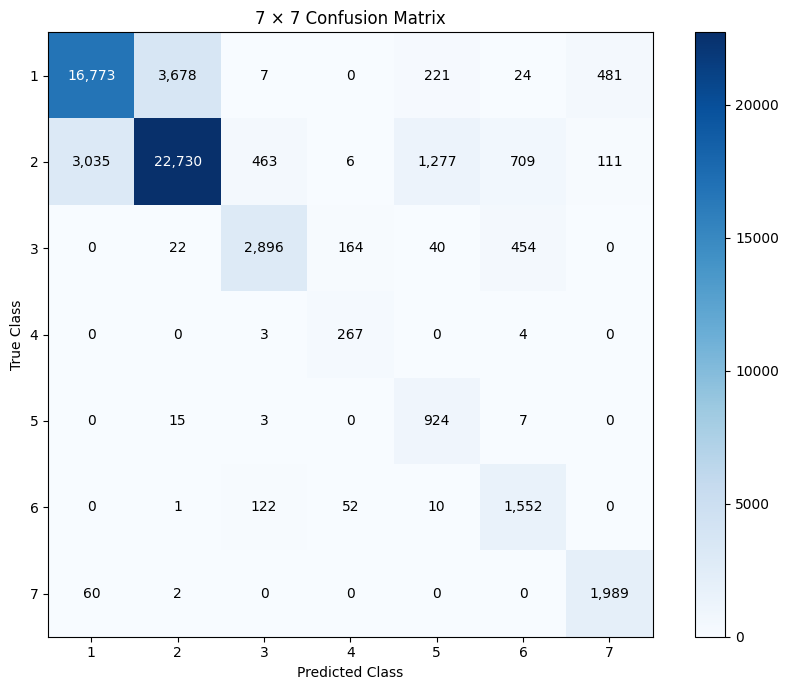

In [39]:
plt.figure(figsize=(9, 7))

plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)

plt.title("7 × 7 Confusion Matrix")

plt.colorbar()

classes = np.arange(1, 8)

plt.xticks(
    np.arange(7),
    classes
)

plt.yticks(
    np.arange(7),
    classes
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

threshold = cm.max() / 2

for i in range(7):

    for j in range(7):

        plt.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )

plt.tight_layout()

plt.show()


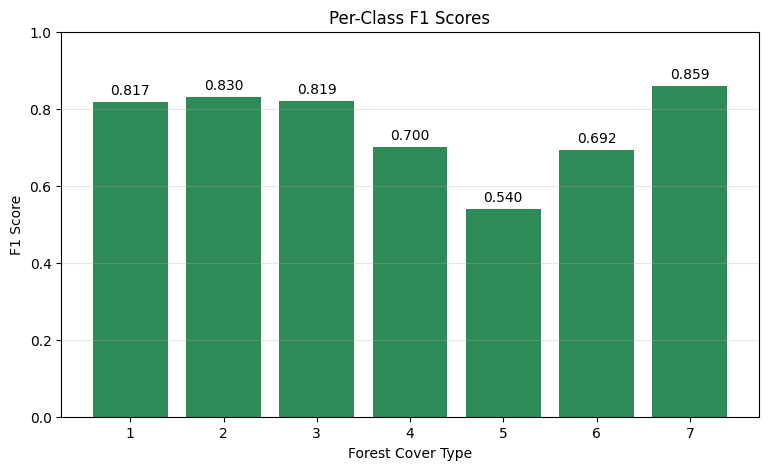

In [40]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    classes,
    f1_per_class,
    color="seagreen"
)

plt.xlabel("Forest Cover Type")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Scores")

plt.xticks(classes)
plt.ylim(0, 1)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar, score in zip(
    bars,
    f1_per_class
):

    plt.text(
        bar.get_x() +
        bar.get_width() / 2,
        score + 0.02,
        f"{score:.3f}",
        ha="center"
    )

plt.show()


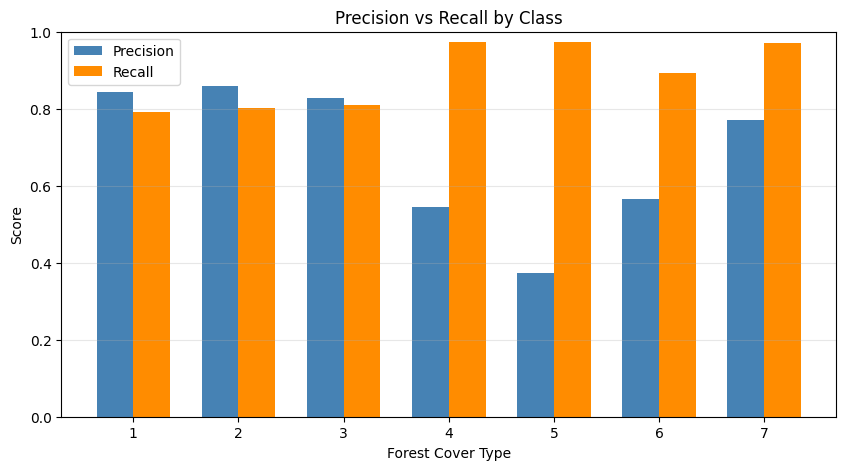

In [41]:
x = np.arange(7)
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    precision_per_class,
    width,
    label="Precision",
    color="steelblue"
)

plt.bar(
    x + width / 2,
    recall_per_class,
    width,
    label="Recall",
    color="darkorange"
)

plt.xlabel("Forest Cover Type")
plt.ylabel("Score")
plt.title("Precision vs Recall by Class")

plt.xticks(
    x,
    classes
)

plt.ylim(0, 1)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


In [42]:
tradeoff_df = pd.DataFrame({
    "Class": classes,
    "Precision": precision_per_class,
    "Recall": recall_per_class,
    "Difference": (
        precision_per_class -
        recall_per_class
    )
})

print(
    tradeoff_df.to_string(
        index=False
    )
)


 Class  Precision   Recall  Difference
     1   0.844222 0.791777    0.052445
     2   0.859422 0.802301    0.057121
     3   0.828849 0.809843    0.019006
     4   0.546012 0.974453   -0.428440
     5   0.373786 0.973656   -0.599870
     6   0.564364 0.893495   -0.329131
     7   0.770632 0.969771   -0.199139


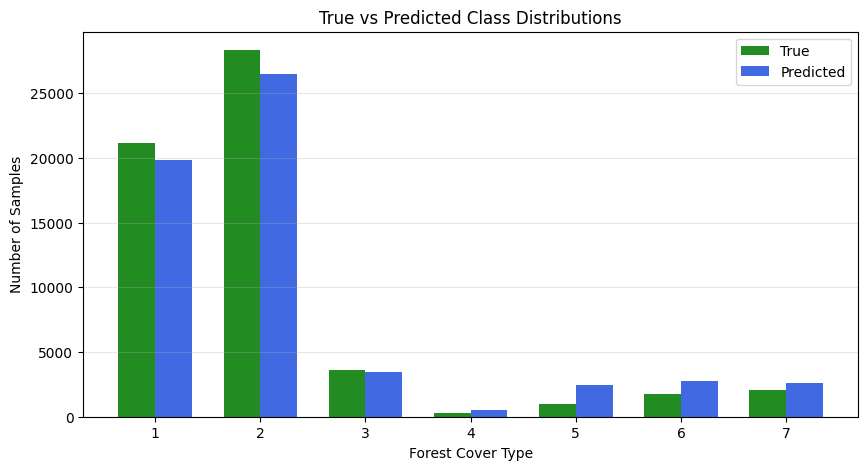

In [43]:
true_counts = np.bincount(
    y_test,
    minlength=7
)

predicted_counts = np.bincount(
    test_predictions,
    minlength=7
)

x = np.arange(7)
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    true_counts,
    width,
    label="True",
    color="forestgreen"
)

plt.bar(
    x + width / 2,
    predicted_counts,
    width,
    label="Predicted",
    color="royalblue"
)

plt.xlabel("Forest Cover Type")
plt.ylabel("Number of Samples")
plt.title("True vs Predicted Class Distributions")

plt.xticks(
    x,
    classes
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


In [44]:
true_percentage = (
    true_counts /
    len(y_test) *
    100
)

predicted_percentage = (
    predicted_counts /
    len(test_predictions) *
    100
)

distribution_df = pd.DataFrame({
    "Class": classes,
    "True Count": true_counts,
    "Predicted Count": predicted_counts,
    "True %": true_percentage,
    "Predicted %": predicted_percentage
})

print(
    distribution_df.to_string(
        index=False
    )
)


 Class  True Count  Predicted Count    True %  Predicted %
     1       21184            19868 36.460019    34.195036
     2       28331            26448 48.760800    45.519948
     3        3576             3494  6.154693     6.013562
     4         274              489  0.471584     0.841623
     5         949             2472  1.633334     4.254587
     6        1737             2750  2.989570     4.733056
     7        2051             2581  3.529999     4.442188


In [45]:
print("\n")
print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print("\nDataset")
print("Samples       :", X.shape[0])
print("Features      :", X.shape[1])
print("Classes       :", K)

print("\nArchitecture")
print("54 → 64 → 32 → 16 → 7")

print("\nTraining")
print("Optimizer     : Mini-batch SGD")
print("Batch size    :", batch_size)
print("Learning rate :", learning_rate)
print("Early stopping: Yes")
print("Patience      :", patience)

print("\nPerformance")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall   : {macro_recall:.4f}")
print(f"Macro F1       : {macro_f1:.4f}")

print("\n" + "=" * 60)




FINAL MODEL SUMMARY

Dataset
Samples       : 581012
Features      : 54
Classes       : 7

Architecture
54 → 64 → 32 → 16 → 7

Training
Optimizer     : Mini-batch SGD
Batch size    : 128
Learning rate : 0.01
Early stopping: Yes
Patience      : 15

Performance
Accuracy       : 0.8112
Macro Precision: 0.6839
Macro Recall   : 0.8879
Macro F1       : 0.7510

